In [142]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from scipy.stats import chi2
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import itertools


np.random.seed(42)

In [2]:
end_date   = "2026-08-05"
start_date = "2016-08-05"

tickers = {
    'NIFTY':  '^NSEI',
    'Gold':   'GC=F',
    'USDINR': 'INR=X',
    'Treasury': 'TLT',
    'Crypto': 'BTC-USD'
}

data = yf.download(list(tickers.values()), start=start_date, end=end_date, auto_adjust=True)['Close']

[*********************100%***********************]  5 of 5 completed


In [227]:
prices = data.copy()

In [228]:
prices.columns

Index(['BTC-USD', 'GC=F', 'INR=X', 'TLT', '^NSEI'], dtype='str', name='Ticker')

In [229]:
prices.columns = ['Crypto','Gold','USDINR','Treasury','NIFTY']

In [230]:
prices.dropna(inplace=True)

In [231]:
prices.shape

(2380, 5)

In [232]:
print(prices)

                  Crypto         Gold     USDINR    Treasury         NIFTY
Date                                                                      
2016-08-05    575.043030  1336.400024  66.841003  103.992676   8683.150391
2016-08-08    591.054016  1333.400024  66.834999  104.188667   8711.349609
2016-08-09    587.801025  1339.000000  66.793999  105.213501   8678.250000
2016-08-10    592.103027  1344.300049  66.782997  105.620338   8575.299805
2016-08-11    589.119995  1342.500000  66.758003  104.678383   8592.150391
...                  ...          ...        ...         ...           ...
2026-07-29  63908.167969  4034.699951  95.598701   82.517593  24250.199219
2026-07-30  64725.308594  4100.100098  95.728600   82.467796  24317.150391
2026-07-31  62813.746094  4049.100098  95.684799   81.919998  24383.599609
2026-08-03  63460.898438  4033.699951  95.402199   82.190002  24774.300781
2026-08-04  64055.953125  4095.399902  95.331596   82.820000  24614.900391

[2380 rows x 5 columns]


In [233]:
prices.isna().sum()

Crypto      0
Gold        0
USDINR      0
Treasury    0
NIFTY       0
dtype: int64

In [234]:
(prices == 0).sum()

Crypto      0
Gold        0
USDINR      0
Treasury    0
NIFTY       0
dtype: int64

In [235]:
prices.min()

Crypto       572.302979
Gold        1127.800049
USDINR        63.264999
Treasury      73.406975
NIFTY       7610.250000
dtype: float64

In [236]:
prices.max()

Crypto      124752.531250
Gold          5318.399902
USDINR          96.876900
Treasury       142.127029
NIFTY        26328.550781
dtype: float64

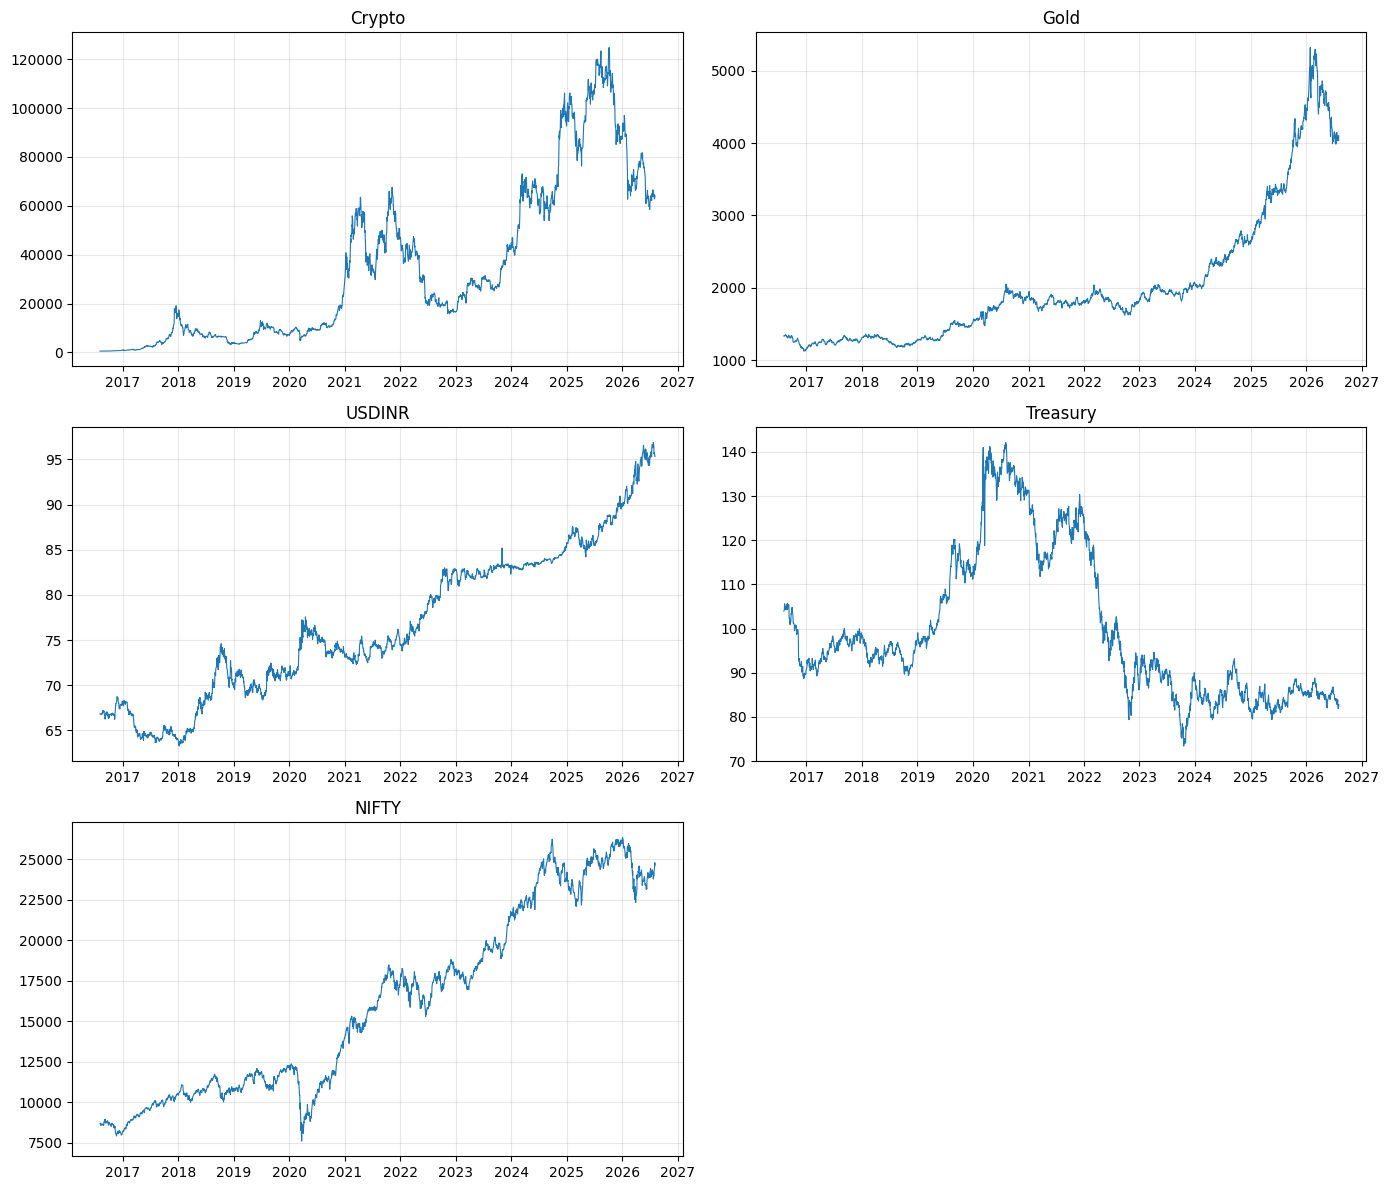

In [237]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()
for i, col in enumerate(prices.columns):
    axes[i].plot(prices.index, prices[col], linewidth=0.8)
    axes[i].set_title(col, fontsize=12)
    axes[i].grid(True, alpha=0.3)
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()


In [238]:
returns = 100 * np.log(prices / prices.shift(1))

In [239]:
returns.dropna(inplace=True)

In [240]:
returns.shape

(2379, 5)

In [241]:
print(returns)

              Crypto      Gold    USDINR  Treasury     NIFTY
Date                                                        
2016-08-08  2.746254 -0.224736 -0.008983  0.188289  0.324232
2016-08-09 -0.551891  0.419098 -0.061364  0.978826 -0.380683
2016-08-10  0.729215  0.395040 -0.016472  0.385932 -1.193394
2016-08-11 -0.505076 -0.133992 -0.037433 -0.895832  0.196309
2016-08-16 -2.002704  0.594135  0.159996 -0.374977  0.584861
...              ...       ...       ...       ...       ...
2026-07-29  0.057607 -0.039651 -0.183307 -1.663811  1.098162
2026-07-30  1.270512  1.607945  0.135786 -0.060365  0.275705
2026-07-31 -2.997836 -1.251673 -0.045765 -0.666473  0.272888
2026-08-03  1.025001 -0.381060 -0.295782  0.329053  1.589610
2026-08-04  0.933303  1.518031 -0.074032  0.763590 -0.645489

[2379 rows x 5 columns]


In [242]:
print(returns.describe().T)

           count      mean       std        min       25%       50%       75%  \
Crypto    2379.0  0.198111  4.310716 -46.473018 -1.618321  0.189290  2.090971   
Gold      2379.0  0.047074  1.083659 -12.065692 -0.435752  0.081320  0.602850   
USDINR    2379.0  0.014924  0.390225  -2.311533 -0.175397  0.005397  0.186561   
Treasury  2379.0 -0.009569  0.958410  -9.011046 -0.556247  0.007864  0.544611   
NIFTY     2379.0  0.043799  1.046638 -13.903756 -0.423503  0.071512  0.591563   

                max  
Crypto    22.511895  
Gold       5.905438  
USDINR     2.639534  
Treasury   7.250275  
NIFTY      8.400295  


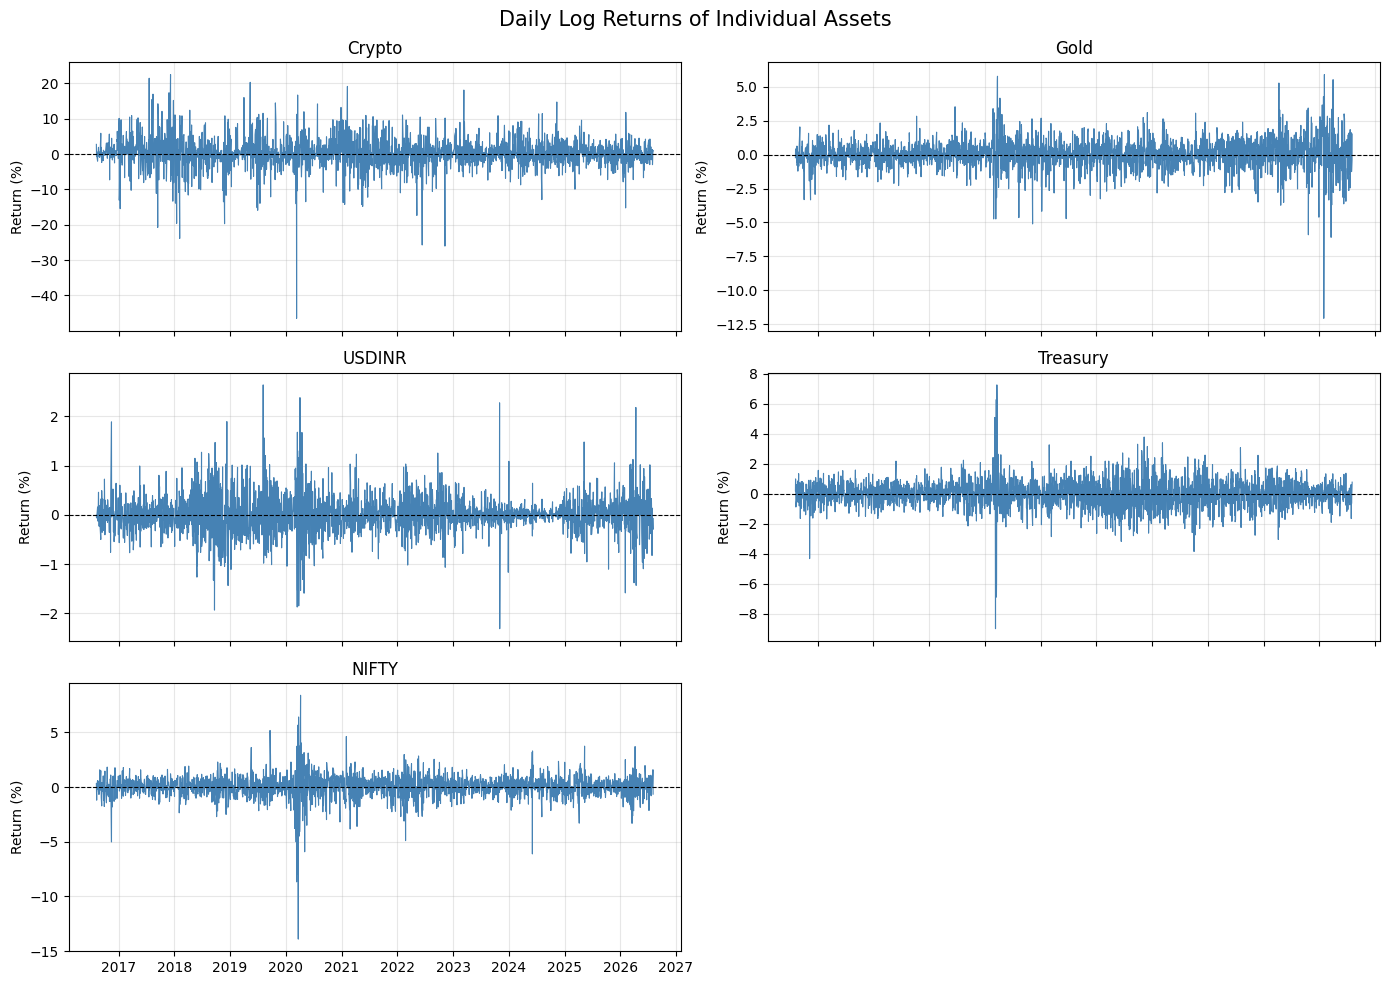

In [243]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

for i, col in enumerate(returns.columns):
    axes[i].plot(
        returns.index,
        returns[col],
        color='steelblue',
        linewidth=0.8
    )
    axes[i].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('Return (%)')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_visible(False)

plt.suptitle('Daily Log Returns of Individual Assets', fontsize=15)
plt.tight_layout()
plt.show()

In [244]:
port_ret = returns.mean(axis=1)

In [245]:
port_ret.name = 'Portfolio'

In [246]:
print(port_ret)

Date
2016-08-08    0.605011
2016-08-09    0.080797
2016-08-10    0.060064
2016-08-11   -0.275205
2016-08-16   -0.207738
                ...   
2026-07-29   -0.146200
2026-07-30    0.645916
2026-07-31   -0.937772
2026-08-03    0.453364
2026-08-04    0.499081
Name: Portfolio, Length: 2379, dtype: float64


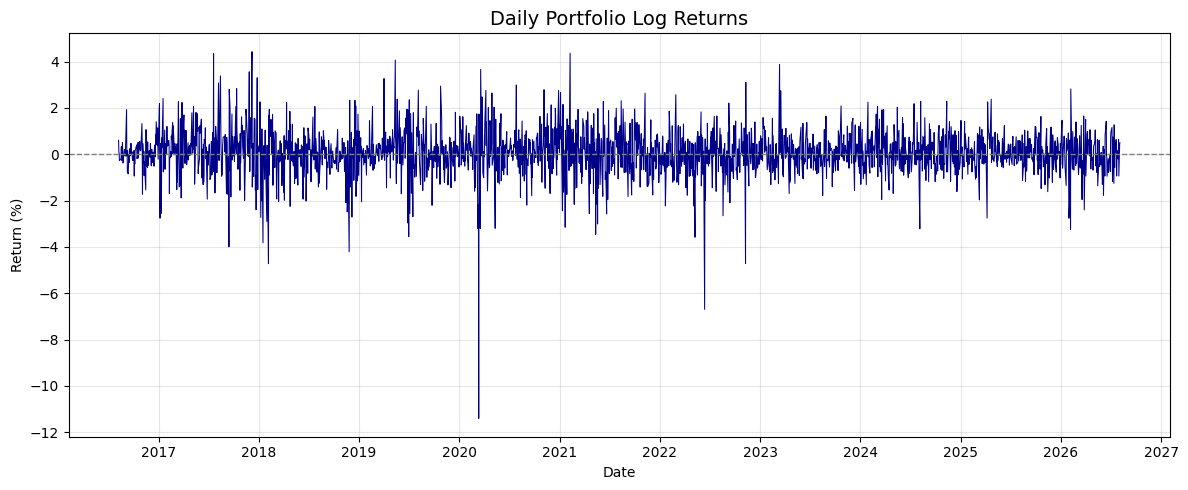

In [247]:
plt.figure(figsize=(12, 5))

plt.plot(
    port_ret.index,
    port_ret,
    linewidth=.75,
    color='darkblue'
)

plt.axhline(0, color='grey', linestyle='--', linewidth=1)

plt.title('Daily Portfolio Log Returns', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

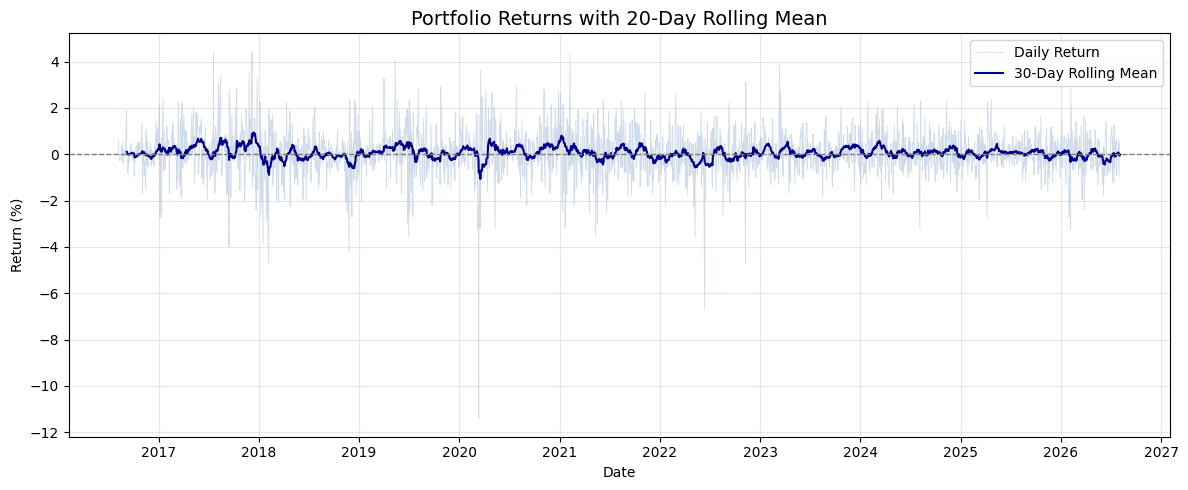

In [248]:
plt.figure(figsize=(12, 5))

plt.plot(
    port_ret.index,
    port_ret,
    color='lightsteelblue',
    linewidth=0.6,
    alpha=0.6,
    label='Daily Return'
)

plt.plot(
    port_ret.index,
    port_ret.rolling(20).mean(),
    color='darkblue',
    linewidth=1.5,
    label='30-Day Rolling Mean'
)

plt.axhline(0, color='grey', linestyle='--', linewidth=1)

plt.title('Portfolio Returns with 20-Day Rolling Mean', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [249]:
summary = port_ret.describe()

summary["skew"] = port_ret.skew()
summary["kurtosis"] = port_ret.kurtosis()

print(summary)

count       2379.000000
mean           0.058868
std            0.975925
min          -11.400519
25%           -0.420020
50%            0.058247
75%            0.551466
max            4.429944
skew          -0.862754
kurtosis      10.925839
Name: Portfolio, dtype: float64


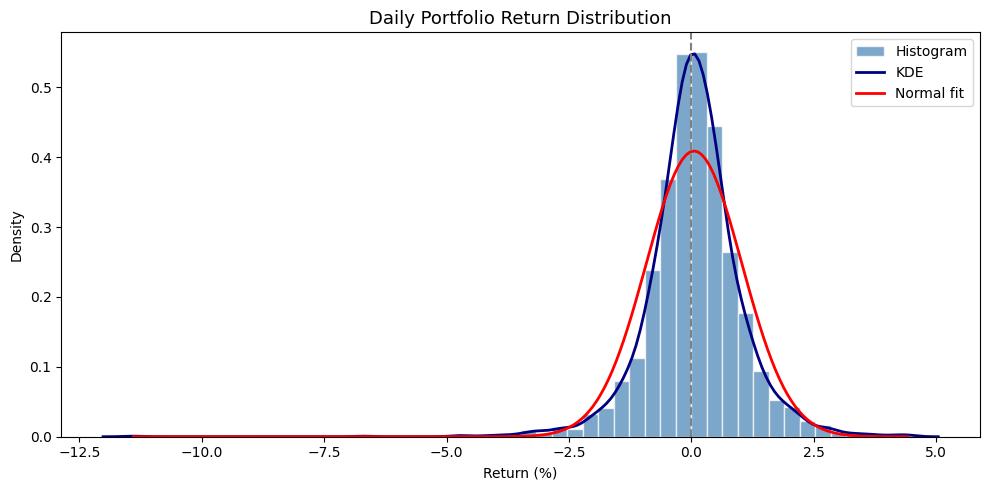

In [250]:
plt.figure(figsize=(10, 5))

plt.hist(
    port_ret,
    bins=50,
    density=True,
    alpha=0.7,
    color='steelblue',
    edgecolor='white',
    label='Histogram'
)

sns.kdeplot(
    port_ret,
    color='navy',
    linewidth=2,
    label='KDE'
)

x = np.linspace(port_ret.min(), port_ret.max(), 200)
plt.plot(
    x,
    stats.norm.pdf(x, port_ret.mean(), port_ret.std()),
    'r-',
    lw=2,
    label='Normal fit'
)

plt.axvline(0, color='grey', linestyle='--')
plt.title('Daily Portfolio Return Distribution', fontsize=13)
plt.xlabel('Return (%)')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.show()

In [251]:
cumulative = (1 + port_ret/100).cumprod()

In [252]:
summary = cumulative.describe()

summary["skew"] = cumulative.skew()
summary["kurtosis"] = cumulative.kurtosis()

print(summary)

count       2379.000000
mean           2.423188
std            0.853712
min            0.985116
25%            1.712417
50%            2.395913
75%            3.054854
max            4.135229
skew           0.231243
kurtosis      -0.958968
Name: Portfolio, dtype: float64


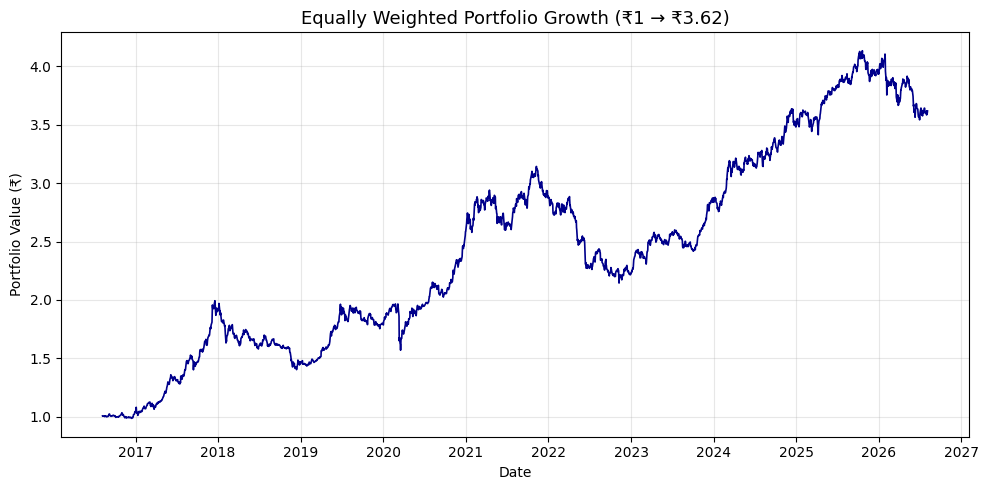

In [253]:
plt.figure(figsize=(10, 5))

plt.plot(cumulative.index, cumulative, linewidth=1.2, color='darkblue')
plt.title(f'Equally Weighted Portfolio Growth (₹1 → ₹{cumulative.iloc[-1]:.2f})', fontsize=13)
plt.ylabel('Portfolio Value (₹)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [254]:
for p in prices.columns:
    print(p)
    adf_stat, p_val, used_lag, nobs, crit_vals, icbest = adfuller(prices[p].dropna(), autolag='AIC')
    print(f"Test Statistic: {adf_stat:.4f}")
    print(f"p-value: {p_val:.4f}")
    print(f"Lags Used: {used_lag}")
    print(f"Observations: {nobs}")
    for key, val in crit_vals.items():
        print(f" {key}: {val:.4f}")

Crypto
Test Statistic: -1.3870
p-value: 0.5885
Lags Used: 23
Observations: 2356
 1%: -3.4331
 5%: -2.8628
 10%: -2.5674
Gold
Test Statistic: 0.3232
p-value: 0.9784
Lags Used: 27
Observations: 2352
 1%: -3.4331
 5%: -2.8628
 10%: -2.5674
USDINR
Test Statistic: 0.6608
p-value: 0.9890
Lags Used: 6
Observations: 2373
 1%: -3.4331
 5%: -2.8628
 10%: -2.5674
Treasury
Test Statistic: -1.2405
p-value: 0.6559
Lags Used: 18
Observations: 2361
 1%: -3.4331
 5%: -2.8628
 10%: -2.5674
NIFTY
Test Statistic: -0.4703
p-value: 0.8977
Lags Used: 0
Observations: 2379
 1%: -3.4331
 5%: -2.8628
 10%: -2.5674


In [255]:
adf_stat, p_val, used_lag, nobs, crit_vals, icbest = adfuller(port_ret.dropna(), autolag='AIC')
print(f"Test Statistic: {adf_stat:.4f}")
print(f"p-value: {p_val:.4f}")
print(f"Lags Used: {used_lag}")
print(f"Observations: {nobs}")
for key, val in crit_vals.items():
    print(f" {key}: {val:.4f}")

Test Statistic: -26.6080
p-value: 0.0000
Lags Used: 2
Observations: 2376
 1%: -3.4331
 5%: -2.8628
 10%: -2.5674


In [256]:
lb_ret = acorr_ljungbox(port_ret, lags=[5, 10, 20], return_df=True)
print(lb_ret)

      lb_stat  lb_pvalue
5    7.017391   0.219350
10  16.656281   0.082324
20  26.677014   0.144598


In [257]:
lb_sq = acorr_ljungbox(port_ret**2, lags=[5, 10, 20], return_df=True)
print(lb_sq)

       lb_stat     lb_pvalue
5    79.548651  1.042968e-15
10   94.102444  8.197465e-16
20  102.837228  3.899510e-13


In [258]:
arch_test = het_arch(port_ret.dropna())
print(f"ARCH-LM Test Statistic: {arch_test[0]:.4f}")
print(f"p-value: {arch_test[1]:.4f}")

ARCH-LM Test Statistic: 69.5266
p-value: 0.0000


In [259]:
am_garch_n = arch_model(port_ret, mean='Constant', vol='GARCH', p=1, q=1, dist='normal')
res_garch_n = am_garch_n.fit(disp='off')
print(res_garch_n.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:              Portfolio   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3179.25
Distribution:                  Normal   AIC:                           6366.49
Method:            Maximum Likelihood   BIC:                           6389.59
                                        No. Observations:                 2379
Date:                Thu, Aug 06 2026   Df Residuals:                     2378
Time:                        10:25:04   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0591  1.758e-02      3.362  7.751e-04 [2.

In [260]:
am_garch_t = arch_model(port_ret, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
res_garch_t = am_garch_t.fit(disp='off')
print(res_garch_t.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                    Portfolio   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3026.29
Distribution:      Standardized Student's t   AIC:                           6062.58
Method:                  Maximum Likelihood   BIC:                           6091.45
                                              No. Observations:                 2379
Date:                      Thu, Aug 06 2026   Df Residuals:                     2378
Time:                              10:25:04   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

In [261]:
am_egarch = arch_model(port_ret, mean='Constant', vol='EGARCH', p=1, o=1, q=1, dist='t')
res_egarch = am_egarch.fit(disp='off')
print(res_egarch.summary())

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                    Portfolio   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -3022.76
Distribution:      Standardized Student's t   AIC:                           6057.52
Method:                  Maximum Likelihood   BIC:                           6092.16
                                              No. Observations:                 2379
Date:                      Thu, Aug 06 2026   Df Residuals:                     2378
Time:                              10:25:05   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

In [262]:
am_tgarch = arch_model(port_ret, mean='Constant', vol='GARCH', p=1, o=1, q=1, dist='t')
res_tgarch = am_tgarch.fit(disp='off')
print(res_tgarch.summary())

                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                    Portfolio   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -3026.14
Distribution:      Standardized Student's t   AIC:                           6064.29
Method:                  Maximum Likelihood   BIC:                           6098.94
                                              No. Observations:                 2379
Date:                      Thu, Aug 06 2026   Df Residuals:                     2378
Time:                              10:25:05   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

In [263]:
models = ['GARCH-n', 'GARCH-t', 'EGARCH-t', 'TGARCH-t']
aic_vals = [res_garch_n.aic, res_garch_t.aic, res_egarch.aic, res_tgarch.aic]
bic_vals = [res_garch_n.bic, res_garch_t.bic, res_egarch.bic, res_tgarch.bic]

model_comparison = pd.DataFrame({
    'Model': models,
    'AIC': aic_vals,
    'BIC': bic_vals
})
print(model_comparison)

      Model          AIC          BIC
0   GARCH-n  6366.493735  6389.591477
1   GARCH-t  6062.582671  6091.454848
2  EGARCH-t  6057.516636  6092.163249
3  TGARCH-t  6064.289794  6098.936407


In [264]:
best_idx = np.argmin(aic_vals)
best_model = models[best_idx]
print(f"SELECTED MODEL: {best_model} (Lowest AIC = {aic_vals[best_idx]:.2f})")

SELECTED MODEL: EGARCH-t (Lowest AIC = 6057.52)


In [265]:
best_idx = np.argmin(bic_vals)
best_model = models[best_idx]
print(f"SELECTED MODEL: {best_model} (Lowest BIC = {bic_vals[best_idx]:.2f})")

SELECTED MODEL: GARCH-t (Lowest BIC = 6091.45)


In [266]:
std_resid = res_garch_t.std_resid.dropna()

In [267]:
print(std_resid.mean())

0.00407944023460222


In [268]:
print(std_resid.std())

0.9905543595377547


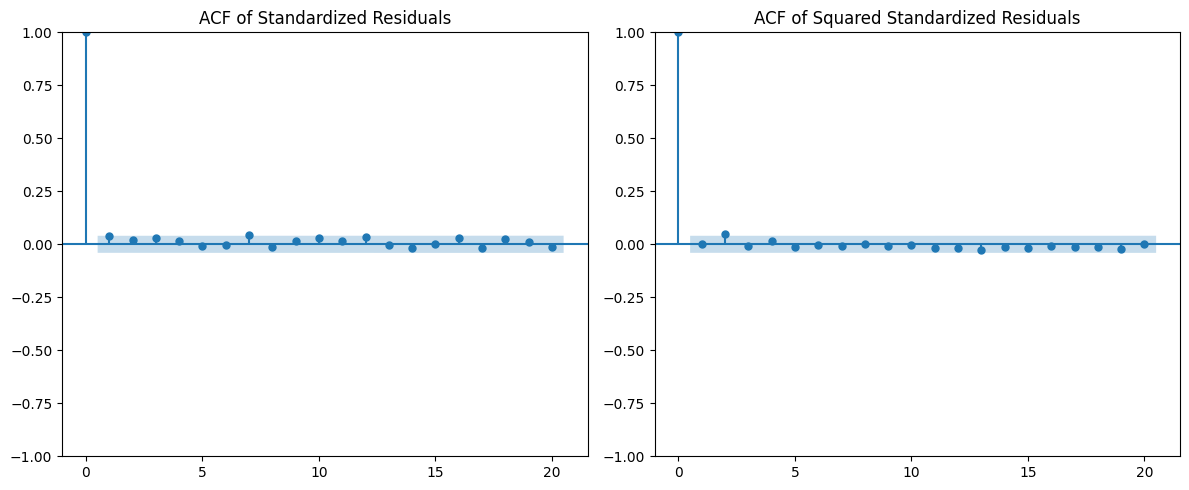

In [269]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(std_resid, lags=20, ax=axes[0])
axes[0].set_title('ACF of Standardized Residuals')

plot_acf(std_resid**2, lags=20, ax=axes[1])
axes[1].set_title('ACF of Squared Standardized Residuals')
plt.tight_layout()
plt.show()

In [270]:
lb_std = acorr_ljungbox(std_resid, lags=[5, 10, 20], return_df=True)
print(lb_std)

      lb_stat  lb_pvalue
5    7.566535   0.181798
10  15.337748   0.120225
20  23.988838   0.242880


In [271]:
lb_std2 = acorr_ljungbox(std_resid**2, lags=[5, 10, 20], return_df=True)
print(lb_std2)

      lb_stat  lb_pvalue
5    6.927803   0.226065
10   7.274255   0.699325
20  13.193495   0.868928


In [272]:
nu_hat = res_garch_t.params['nu']

theoretical = stats.t.ppf((np.arange(len(std_resid)) + 0.5) / len(std_resid), df=nu_hat)
sample = np.sort(std_resid)

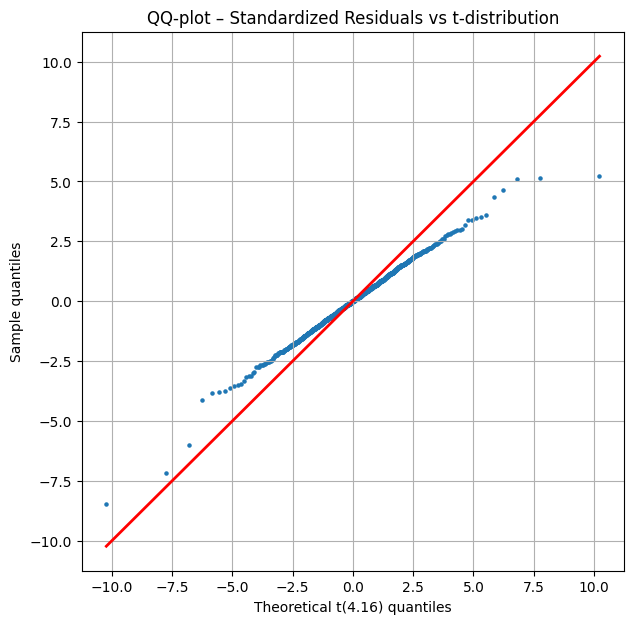

In [273]:
plt.figure(figsize=(7,7))
plt.scatter(theoretical, sample, s=5)
mn = min(theoretical.min(), sample.min())
mx = max(theoretical.max(), sample.max())
plt.plot([mn, mx], [mn, mx], 'r-', lw=2)
plt.xlabel(f'Theoretical t({nu_hat:.2f}) quantiles')
plt.ylabel('Sample quantiles')
plt.title('QQ‑plot – Standardized Residuals vs t‑distribution')
plt.grid(True)
plt.show()

In [274]:
var_hist_95 = -np.percentile(port_ret, 5)
var_hist_99 = -np.percentile(port_ret, 1)

ES_hist_95 = -port_ret[port_ret <= -var_hist_95].mean()
ES_hist_99 = -port_ret[port_ret <= -var_hist_99].mean()

In [275]:
forecast = res_garch_t.forecast(horizon=1)
mu_t = forecast.mean.iloc[-1, 0]
sigma_t = np.sqrt(forecast.variance.iloc[-1, 0])
nu = res_garch_t.params['nu']

var_garch_95 = -(mu_t + stats.t.ppf(0.05, nu) * sigma_t)
var_garch_99 = -(mu_t + stats.t.ppf(0.01, nu) * sigma_t)

q_05 = stats.t.ppf(0.05, nu)
q_01 = stats.t.ppf(0.01, nu)
ES_garch_95 = -(mu_t - sigma_t * (stats.t.pdf(q_05, nu) / 0.05) * ((nu + q_05**2) / (nu - 1)))
ES_garch_99 = -(mu_t - sigma_t * (stats.t.pdf(q_01, nu) / 0.01) * ((nu + q_01**2) / (nu - 1)))

In [276]:
lambda_ = 0.94
losses = -port_ret  
ewma_var = np.zeros(len(port_ret))
ewma_var[0] = port_ret.iloc[0]**2  
for t in range(1, len(port_ret)):
    ewma_var[t] = lambda_ * ewma_var[t-1] + (1 - lambda_) * port_ret.iloc[t-1]**2
sigma_ewma = np.sqrt(lambda_ * ewma_var[-1] + (1 - lambda_) * port_ret.iloc[-1]**2)
var_ewma_95 = -stats.norm.ppf(0.05) * sigma_ewma
var_ewma_99 = -stats.norm.ppf(0.01) * sigma_ewma

ES_ewma_95 = sigma_ewma * stats.norm.pdf(stats.norm.ppf(0.05)) / 0.05
ES_ewma_99 = sigma_ewma * stats.norm.pdf(stats.norm.ppf(0.01)) / 0.01

In [277]:
var_summary = pd.DataFrame({
    'Method': ['Historical', 'GARCH-t(1,1)', 'EWMA (RiskMetrics)'],
    '95% VaR (%)': [var_hist_95, var_garch_95, var_ewma_95],
    '99% VaR (%)': [var_hist_99, var_garch_99, var_ewma_99]
})
print(var_summary)

               Method  95% VaR (%)  99% VaR (%)
0          Historical     1.414802     2.713851
1        GARCH-t(1,1)     1.550911     2.736988
2  EWMA (RiskMetrics)     1.098166     1.553157


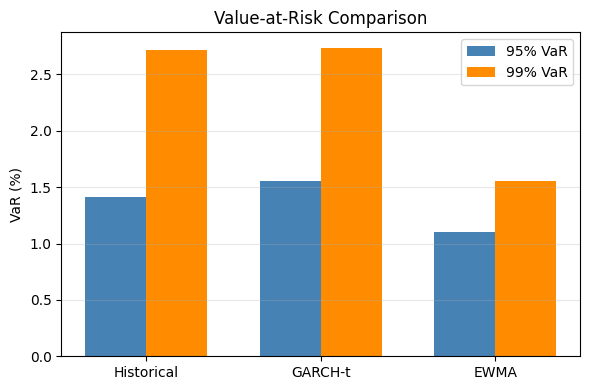

In [278]:
methods = ['Historical', 'GARCH-t', 'EWMA']
var95 = [var_hist_95, var_garch_95, var_ewma_95]
var99 = [var_hist_99, var_garch_99, var_ewma_99]
fig3, ax3 = plt.subplots(figsize=(6,4))
x = np.arange(len(methods))
w = 0.35
ax3.bar(x - w/2, var95, w, label='95% VaR', color='steelblue')
ax3.bar(x + w/2, var99, w, label='99% VaR', color='darkorange')
ax3.set_xticks(x)
ax3.set_xticklabels(methods)
ax3.set_ylabel('VaR (%)')
ax3.set_title('Value-at-Risk Comparison')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

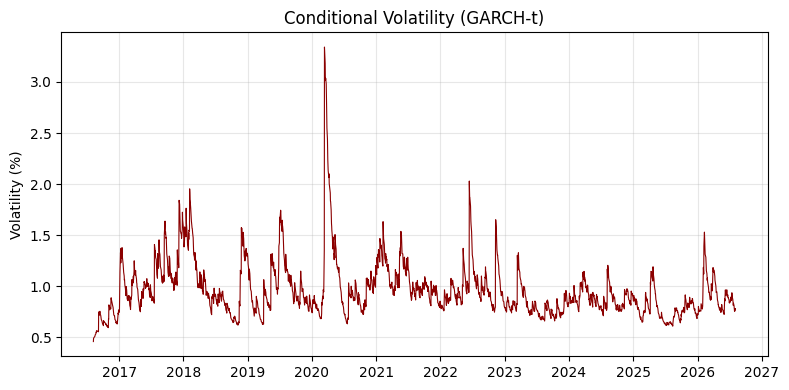

In [279]:
fig2, ax2 = plt.subplots(figsize=(8,4))
vol = res_garch_t.conditional_volatility
ax2.plot(vol.index, vol, color='darkred', linewidth=0.8)
ax2.set_title('Conditional Volatility (GARCH-t)')
ax2.set_ylabel('Volatility (%)')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [280]:
loss = -port_ret.dropna()
loss.name = 'Loss'
print(loss)

Date
2016-08-08   -0.605011
2016-08-09   -0.080797
2016-08-10   -0.060064
2016-08-11    0.275205
2016-08-16    0.207738
                ...   
2026-07-29    0.146200
2026-07-30   -0.645916
2026-07-31    0.937772
2026-08-03   -0.453364
2026-08-04   -0.499081
Name: Loss, Length: 2379, dtype: float64


In [281]:
summary = loss.describe()

summary["skew"] = loss.skew()
summary["kurtosis"] = loss.kurtosis()

print(summary)

count       2379.000000
mean          -0.058868
std            0.975925
min           -4.429944
25%           -0.551466
50%           -0.058247
75%            0.420020
max           11.400519
skew           0.862754
kurtosis      10.925839
Name: Loss, dtype: float64


In [282]:
def mean_excess(losses, thresholds):
    excess_means = []
    for u in thresholds:
        exceedances = losses[losses > u] - u
        if len(exceedances) > 10:
            excess_means.append(exceedances.mean())
        else:
            excess_means.append(np.nan)
    return np.array(excess_means)

In [283]:
threshold_grid = np.percentile(loss, np.linspace(90, 99.5, 50))
mef = mean_excess(loss.values, threshold_grid)

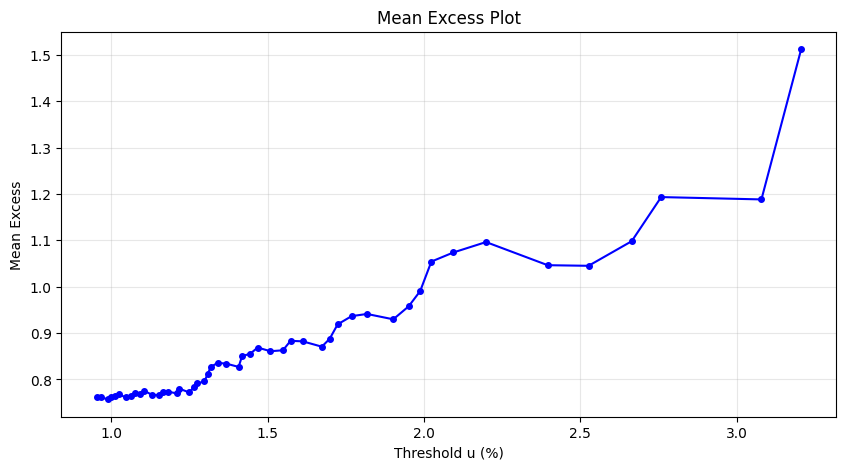

In [285]:
plt.figure(figsize=(10,5))
plt.plot(threshold_grid, mef, 'bo-', markersize=4)
plt.xlabel('Threshold u (%)')
plt.ylabel('Mean Excess')
plt.title('Mean Excess Plot')
plt.grid(True, alpha=0.3)
plt.show()

In [286]:
threshold = np.percentile(loss, 95)
print(threshold)

1.4148022048382412


In [287]:
exceedances = loss[loss > threshold] - threshold
print(len(exceedances))

119


In [288]:
shape, loc, scale = stats.genpareto.fit(exceedances, floc=0)
print(shape)
print(scale)

0.2077325690148072
0.6661505809033808


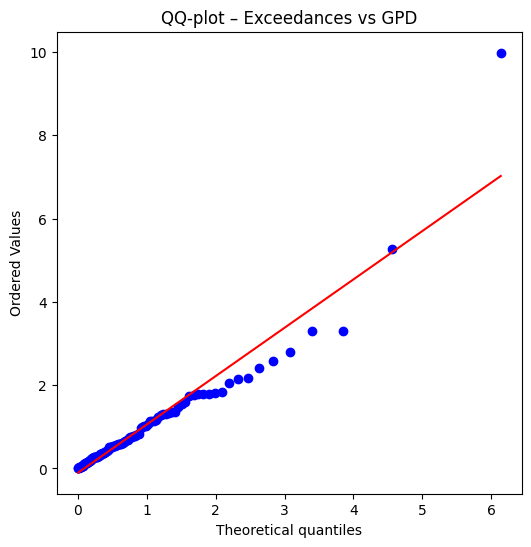

In [289]:
fig, ax = plt.subplots(1, 1, figsize=(6,6))
stats.probplot(exceedances, dist=stats.genpareto, sparams=(shape, 0, scale), plot=ax)
ax.set_title('QQ‑plot – Exceedances vs GPD')
plt.show()

In [290]:
T = len(loss)
Nu = len(exceedances)
u = threshold

q99 = 0.99
q999 = 0.999

VaR_pot_99 = u - (scale/shape) * (1 - (T/Nu * (1 - q99))**(-shape))
VaR_pot_999 = u - (scale/shape) * (1 - (T/Nu * (1 - q999))**(-shape))

ES_pot_99 = VaR_pot_99/(1 - shape) + (scale - shape*u)/(1 - shape)
ES_pot_999 = VaR_pot_999/(1 - shape) + (scale - shape*u)/(1 - shape)

print(f"POT 99% VaR (unadj): {VaR_pot_99:.4f}%")
print(f"POT 99.9% VaR (unadj): {VaR_pot_999:.4f}%")
print(f"POT 99% ES: {ES_pot_99:.4f}%")
print(f"POT 99.9% ES: {ES_pot_999:.4f}%")

POT 99% VaR (unadj): 2.6883%
POT 99.9% VaR (unadj): 5.4363%
POT 99% ES: 3.8630%
POT 99.9% ES: 7.3316%


In [291]:
def extremal_index_runs(exc_indicator, run_length=3):
    exc = np.asarray(exc_indicator, dtype=int)
    clusters = 0
    i = 0
    n = len(exc)
    while i < n:
        if exc[i] == 1:
            clusters += 1
            i += run_length
        else:
            i += 1
    return clusters / np.sum(exc)

exc_ind = (loss.values > u).astype(int)
theta = extremal_index_runs(exc_ind)
print(f"Extremal index (θ) with run length 3: {theta:.4f}")

Extremal index (θ) with run length 3: 0.8403


In [292]:
T_adj = T * theta
VaR_pot_99_adj = u - (scale/shape) * (1 - (T_adj/Nu * (1 - 0.99))**(-shape))
VaR_pot_999_adj = u - (scale/shape) * (1 - (T_adj/Nu * (1 - 0.999))**(-shape))
ES_pot_99_adj = VaR_pot_99_adj/(1 - shape) + (scale - shape*u)/(1 - shape)
ES_pot_999_adj = VaR_pot_999_adj/(1 - shape) + (scale - shape*u)/(1 - shape)

In [293]:
print(f"Adjusted POT 99% VaR: {VaR_pot_99_adj:.4f}%")
print(f"Adjusted POT 99.9% VaR: {VaR_pot_999_adj:.4f}%")
print(f"Adjusted POT 99% ES: {ES_pot_99_adj:.4f}%")
print(f"Adjusted POT 99.9% ES: {ES_pot_999_adj:.4f}%")

Adjusted POT 99% VaR: 2.8532%
Adjusted POT 99.9% VaR: 5.7023%
Adjusted POT 99% ES: 4.0711%
Adjusted POT 99.9% ES: 7.6673%


In [294]:
es_summary = pd.DataFrame({
    'Method': ['Historical', 'GARCH-t', 'EWMA', 'POT (θ-adj)'],
    '95% ES (%)': [ES_hist_95, ES_garch_95, ES_ewma_95, ES_pot_99_adj],
    '99% ES (%)': [ES_hist_99, ES_garch_99, ES_ewma_99, ES_pot_999_adj]
})

print(es_summary)

        Method  95% ES (%)  99% ES (%)
0   Historical    2.261589    3.850313
1      GARCH-t    2.333748    3.793358
2         EWMA    1.377144    1.779397
3  POT (θ-adj)    4.071119    7.667330


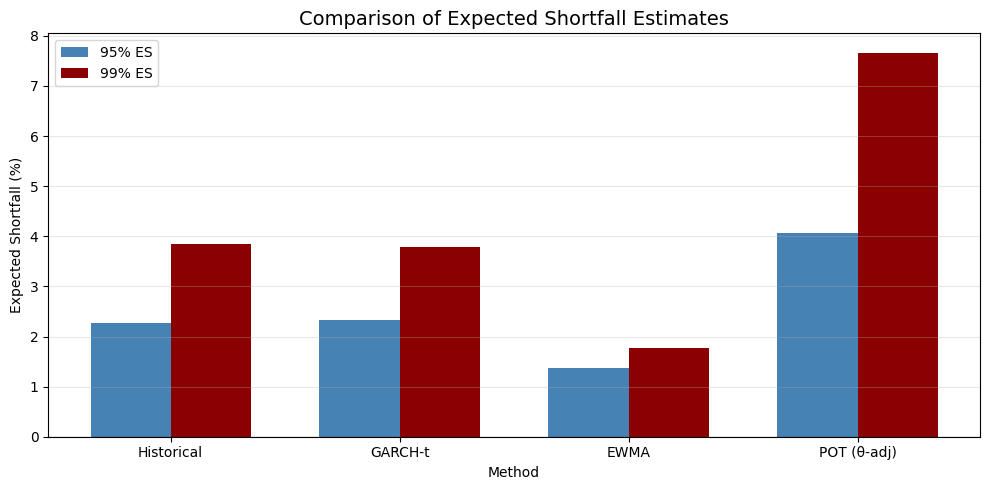

In [295]:
methods = es_summary['Method']
x = np.arange(len(methods))

width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width/2,
    es_summary['95% ES (%)'],
    width,
    label='95% ES',
    color='steelblue'
)

plt.bar(
    x + width/2,
    es_summary['99% ES (%)'],
    width,
    label='99% ES',
    color='darkred'
)

plt.xticks(x, methods)
plt.xlabel('Method')
plt.ylabel('Expected Shortfall (%)')
plt.title('Comparison of Expected Shortfall Estimates', fontsize=14)

plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [296]:
oos_days = 250
train = port_ret.iloc[:-oos_days]  
test  = port_ret.iloc[-oos_days:]  
print(f"Training size: {len(train)}, Test size: {len(test)}")

Training size: 2129, Test size: 250


In [297]:
var_forecasts = []
actual_losses = []

train_data = train.copy()

In [298]:
for i in range(len(test)):
    model = arch_model(train_data, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
    res = model.fit(disp='off')
    
    forecast = res.forecast(horizon=1)
    mu_f = forecast.mean.iloc[-1, 0]
    sigma_f = np.sqrt(forecast.variance.iloc[-1, 0])
    nu_f = res.params['nu']
    
    var_95 = -(mu_f + stats.t.ppf(0.05, nu_f) * sigma_f)
    var_forecasts.append(var_95)
    
    actual_loss = -test.iloc[i]
    actual_losses.append(actual_loss)
    
    train_data = pd.concat([train_data, test.iloc[[i]]])

In [299]:
print(f"Number of forecasts: {len(var_forecasts)}")

Number of forecasts: 250


In [300]:
var_forecasts = np.array(var_forecasts)
actual_losses = np.array(actual_losses)
breaches = actual_losses > var_forecasts
n_breaches = breaches.sum()
expected_breaches = oos_days * 0.05

print(f"Expected breaches (5% of 250): {expected_breaches:.1f}")
print(f"Actual breaches: {n_breaches}")

Expected breaches (5% of 250): 12.5
Actual breaches: 5


In [301]:
def kupiec_pof(n, N, p=0.05):
    if n == 0:
        lr_stat = -2 * N * np.log(1 - p)
    else:
        lr_stat = 2 * ((N - n) * np.log((N - n) / (N * (1 - p))) + n * np.log(n / (N * p)))
    lr_stat = max(0, lr_stat)  # Ensure non-negative
    p_val = 1 - chi2.cdf(lr_stat, df=1)
    return lr_stat, p_val

In [302]:
def christoffersen_cc(breaches):
    n00 = n01 = n10 = n11 = 0
    for i in range(len(breaches)-1):
        if not breaches[i] and not breaches[i+1]: n00 += 1
        elif not breaches[i] and breaches[i+1]: n01 += 1
        elif breaches[i] and not breaches[i+1]: n10 += 1
        else: n11 += 1
            
    n0 = n00 + n01
    n1 = n10 + n11
    p01 = n01 / n0 if n0 > 0 else 0
    p11 = n11 / n1 if n1 > 0 else 0
    p = (n01 + n11) / (n00 + n01 + n10 + n11) if (n00 + n01 + n10 + n11) > 0 else 0
    
    ll0 = 0
    if (n00 + n10) > 0: ll0 += (n00 + n10) * np.log(1 - p)
    if (n01 + n11) > 0: ll0 += (n01 + n11) * np.log(p)
    
    ll1 = 0
    if n00 > 0: ll1 += n00 * np.log(1 - p01)
    if n01 > 0: ll1 += n01 * np.log(p01)
    if n10 > 0: ll1 += n10 * np.log(1 - p11)
    if n11 > 0: ll1 += n11 * np.log(p11)
    
    lr_stat = max(0, -2 * (ll0 - ll1))
    p_val = 1 - chi2.cdf(lr_stat, df=1)
    return lr_stat, p_val

In [303]:
po, pv_kupiec = kupiec_pof(n_breaches, oos_days)
cc, pv_cc = christoffersen_cc(breaches)

In [304]:
print(f"Kupiec POF statistic: {2*po:.4f}, p-value: {pv_kupiec:.4f}")
print(f"Christoffersen CC statistic: {cc:.4f}, p-value: {pv_cc:.4f}")

Kupiec POF statistic: 12.1430, p-value: 0.0137
Christoffersen CC statistic: 0.2049, p-value: 0.6508


In [305]:
oos_days = 250
full_data = port_ret.copy()
train_size = len(full_data) - oos_days
print(f"Training size: {train_size}, Test size: {oos_days}")

mu_forecasts, sigma_forecasts, nu_forecasts = [], [], []
var_forecasts, actual_losses = [], []

for i in range(oos_days):
    current_train = full_data.iloc[:train_size + i]
    
    model = arch_model(current_train, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
    res = model.fit(disp='off')
    
    forecast = res.forecast(horizon=1)
    mu_f = forecast.mean.iloc[-1, 0]
    sigma_f = np.sqrt(forecast.variance.iloc[-1, 0])
    nu_f = res.params['nu']
    
    var_95 = -(mu_f + stats.t.ppf(0.05, nu_f) * sigma_f)
    
    mu_forecasts.append(mu_f)
    sigma_forecasts.append(sigma_f)
    nu_forecasts.append(nu_f)
    var_forecasts.append(var_95)
    actual_losses.append(-full_data.iloc[train_size + i])

var_forecasts = np.array(var_forecasts)
actual_losses = np.array(actual_losses)
mu_forecasts = np.array(mu_forecasts)
sigma_forecasts = np.array(sigma_forecasts)
nu_forecasts = np.array(nu_forecasts)

Training size: 2129, Test size: 250


In [306]:
alpha_es = 0.05
ES_forecasts = []
for mu_f, sigma_f, nu_f in zip(mu_forecasts, sigma_forecasts, nu_forecasts):
    q = stats.t.ppf(alpha_es, nu_f)
    es = -(mu_f - sigma_f * (stats.t.pdf(q, nu_f) / alpha_es) * ((nu_f + q**2) / (nu_f - 1)))
    ES_forecasts.append(es)

ES_forecasts = np.array(ES_forecasts)

breach_mask = actual_losses > var_forecasts

breach_excess = (actual_losses[breach_mask] - ES_forecasts[breach_mask]) / sigma_forecasts[breach_mask]

print(f"Number of breach days: {len(breach_excess)}")
print(f"Mean standardized excess: {breach_excess.mean():.4f}")
print(f"Std excess: {breach_excess.std():.4f}")

t_stat_es, p_val_es = stats.ttest_1samp(breach_excess, popmean=0)
print(f"ES Backtest: t-statistic = {t_stat_es:.4f}, p-value = {p_val_es:.4f}")

Number of breach days: 5
Mean standardized excess: -0.5478
Std excess: 0.5161
ES Backtest: t-statistic = -2.1227, p-value = 0.1010


In [316]:
alpha_975 = 0.025  
q_975 = stats.t.ppf(alpha_975, nu)
ES_975_latest = -(mu_t - sigma_t * (stats.t.pdf(q_975, nu) / alpha_975) * ((nu + q_975**2) / (nu - 1)))

ES_975_forecasts = []
for mu_f, sigma_f, nu_f in zip(mu_forecasts, sigma_forecasts, nu_forecasts):
    q_f = stats.t.ppf(alpha_975, nu_f)
    es_f = -(mu_f - sigma_f * (stats.t.pdf(q_f, nu_f) / alpha_975) * ((nu_f + q_f**2) / (nu_f - 1)))
    ES_975_forecasts.append(es_f)
ES_975_forecasts = np.array(ES_975_forecasts)
ES_975_avg = ES_975_forecasts.mean()

q_pot_975 = 0.975
VaR_pot_975_adj = u - (scale/shape) * (1 - (T_adj/Nu * (1 - q_pot_975))**(-shape))
ES_pot_975_adj = VaR_pot_975_adj/(1 - shape) + (scale - shape*u)/(1 - shape)

n_exceptions = n_breaches
if n_exceptions <= 4:
    m_c = 1.5
elif n_exceptions <= 9:
    m_c = 1.5 + (n_exceptions - 4) * 0.1
else:
    m_c = 2.0

capital_latest = max(ES_975_latest, ES_975_avg) * m_c
capital_pot    = max(ES_pot_975_adj, ES_975_avg) * m_c

print(f"ES(97.5%) Latest (GARCH-t): {ES_975_latest:.4f}%")
print(f"ES(97.5%) 12-Month Average: {ES_975_avg:.4f}%")
print(f"ES(97.5%) POT (θ-adj): {ES_pot_975_adj:.4f}%")
print(f"Backtesting multiplier (m_c): {m_c:.2f}  (from {n_exceptions} exceptions)")
print(f"Capital (GARCH-t): {capital_latest:.4f}% of portfolio value")
print(f"Capital (POT): {capital_pot:.4f}% of portfolio value")

ES(97.5%) Latest (GARCH-t): 2.9091%
ES(97.5%) 12-Month Average: 3.3095%
ES(97.5%) POT (θ-adj): 3.0549%
Backtesting multiplier (m_c): 1.60  (from 5 exceptions)
Capital (GARCH-t): 5.2953% of portfolio value
Capital (POT): 5.2953% of portfolio value


In [307]:
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)

corr_matrix = returns.corr()
print(corr_matrix.round(3))

          Crypto   Gold  USDINR  Treasury  NIFTY
Crypto     1.000  0.098   0.028    -0.021  0.090
Gold       0.098  1.000  -0.013     0.198  0.055
USDINR     0.028 -0.013   1.000    -0.007 -0.151
Treasury  -0.021  0.198  -0.007     1.000 -0.076
NIFTY      0.090  0.055  -0.151    -0.076  1.000


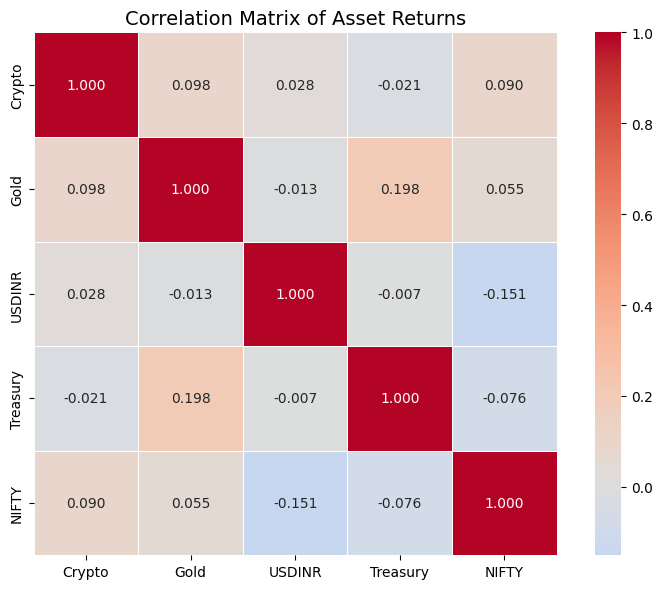

In [308]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,          
    fmt=".3f",           
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title('Correlation Matrix of Asset Returns', fontsize=14)
plt.tight_layout()
plt.show()

In [309]:
pca = PCA()
pca.fit(returns_scaled)

explained_var = pca.explained_variance_ratio_
for i, ev in enumerate(explained_var):
    print(f"PC{i+1}: {ev:.4f} ({ev*100:.1f}%)")

cum_var = np.cumsum(explained_var)
print(f"Cumulative variance (first 3 PCs): {cum_var[2]*100:.1f}%")

PC1: 0.2439 (24.4%)
PC2: 0.2361 (23.6%)
PC3: 0.2075 (20.8%)
PC4: 0.1630 (16.3%)
PC5: 0.1495 (15.0%)
Cumulative variance (first 3 PCs): 68.7%


In [314]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=returns.columns,
    columns=[f'PC{i+1}' for i in range(5)]
)
print(loadings.round(3))

            PC1    PC2    PC3    PC4    PC5
Crypto    0.356  0.212  0.730 -0.530  0.123
Gold      0.700 -0.184  0.039  0.307 -0.617
USDINR   -0.212 -0.491  0.607  0.547  0.217
Treasury  0.503 -0.488 -0.313 -0.144  0.624
NIFTY     0.294  0.665 -0.003  0.552  0.409


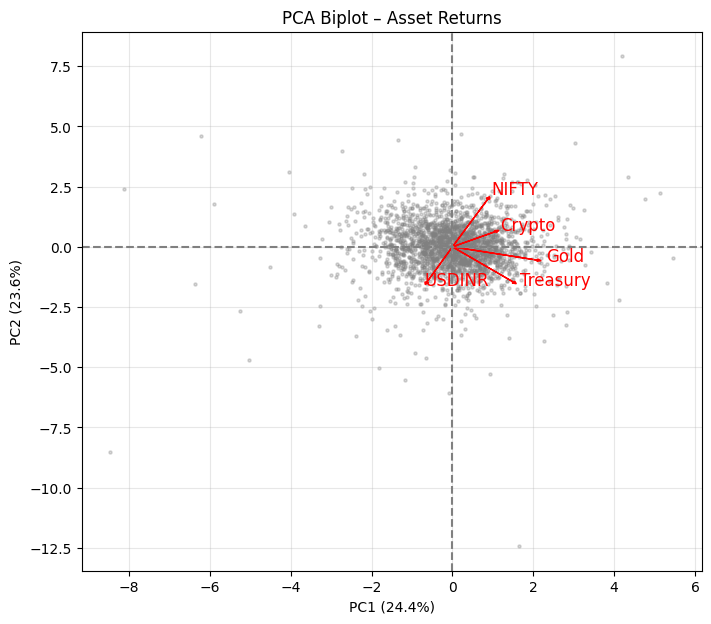

In [311]:
scores = pca.transform(returns_scaled)[:, :2]

plt.figure(figsize=(8,7))
plt.scatter(scores[:, 0], scores[:, 1], alpha=0.3, s=5, c='grey')
for i, asset in enumerate(returns.columns):
    plt.arrow(0, 0, loadings.iloc[i,0]*3, loadings.iloc[i,1]*3,
              color='red', head_width=0.1, head_length=0.1)
    plt.text(loadings.iloc[i,0]*3.3, loadings.iloc[i,1]*3.3, asset, color='red', fontsize=12)
plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}%)')
plt.title('PCA Biplot – Asset Returns')
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.grid(alpha=0.3)
plt.show()

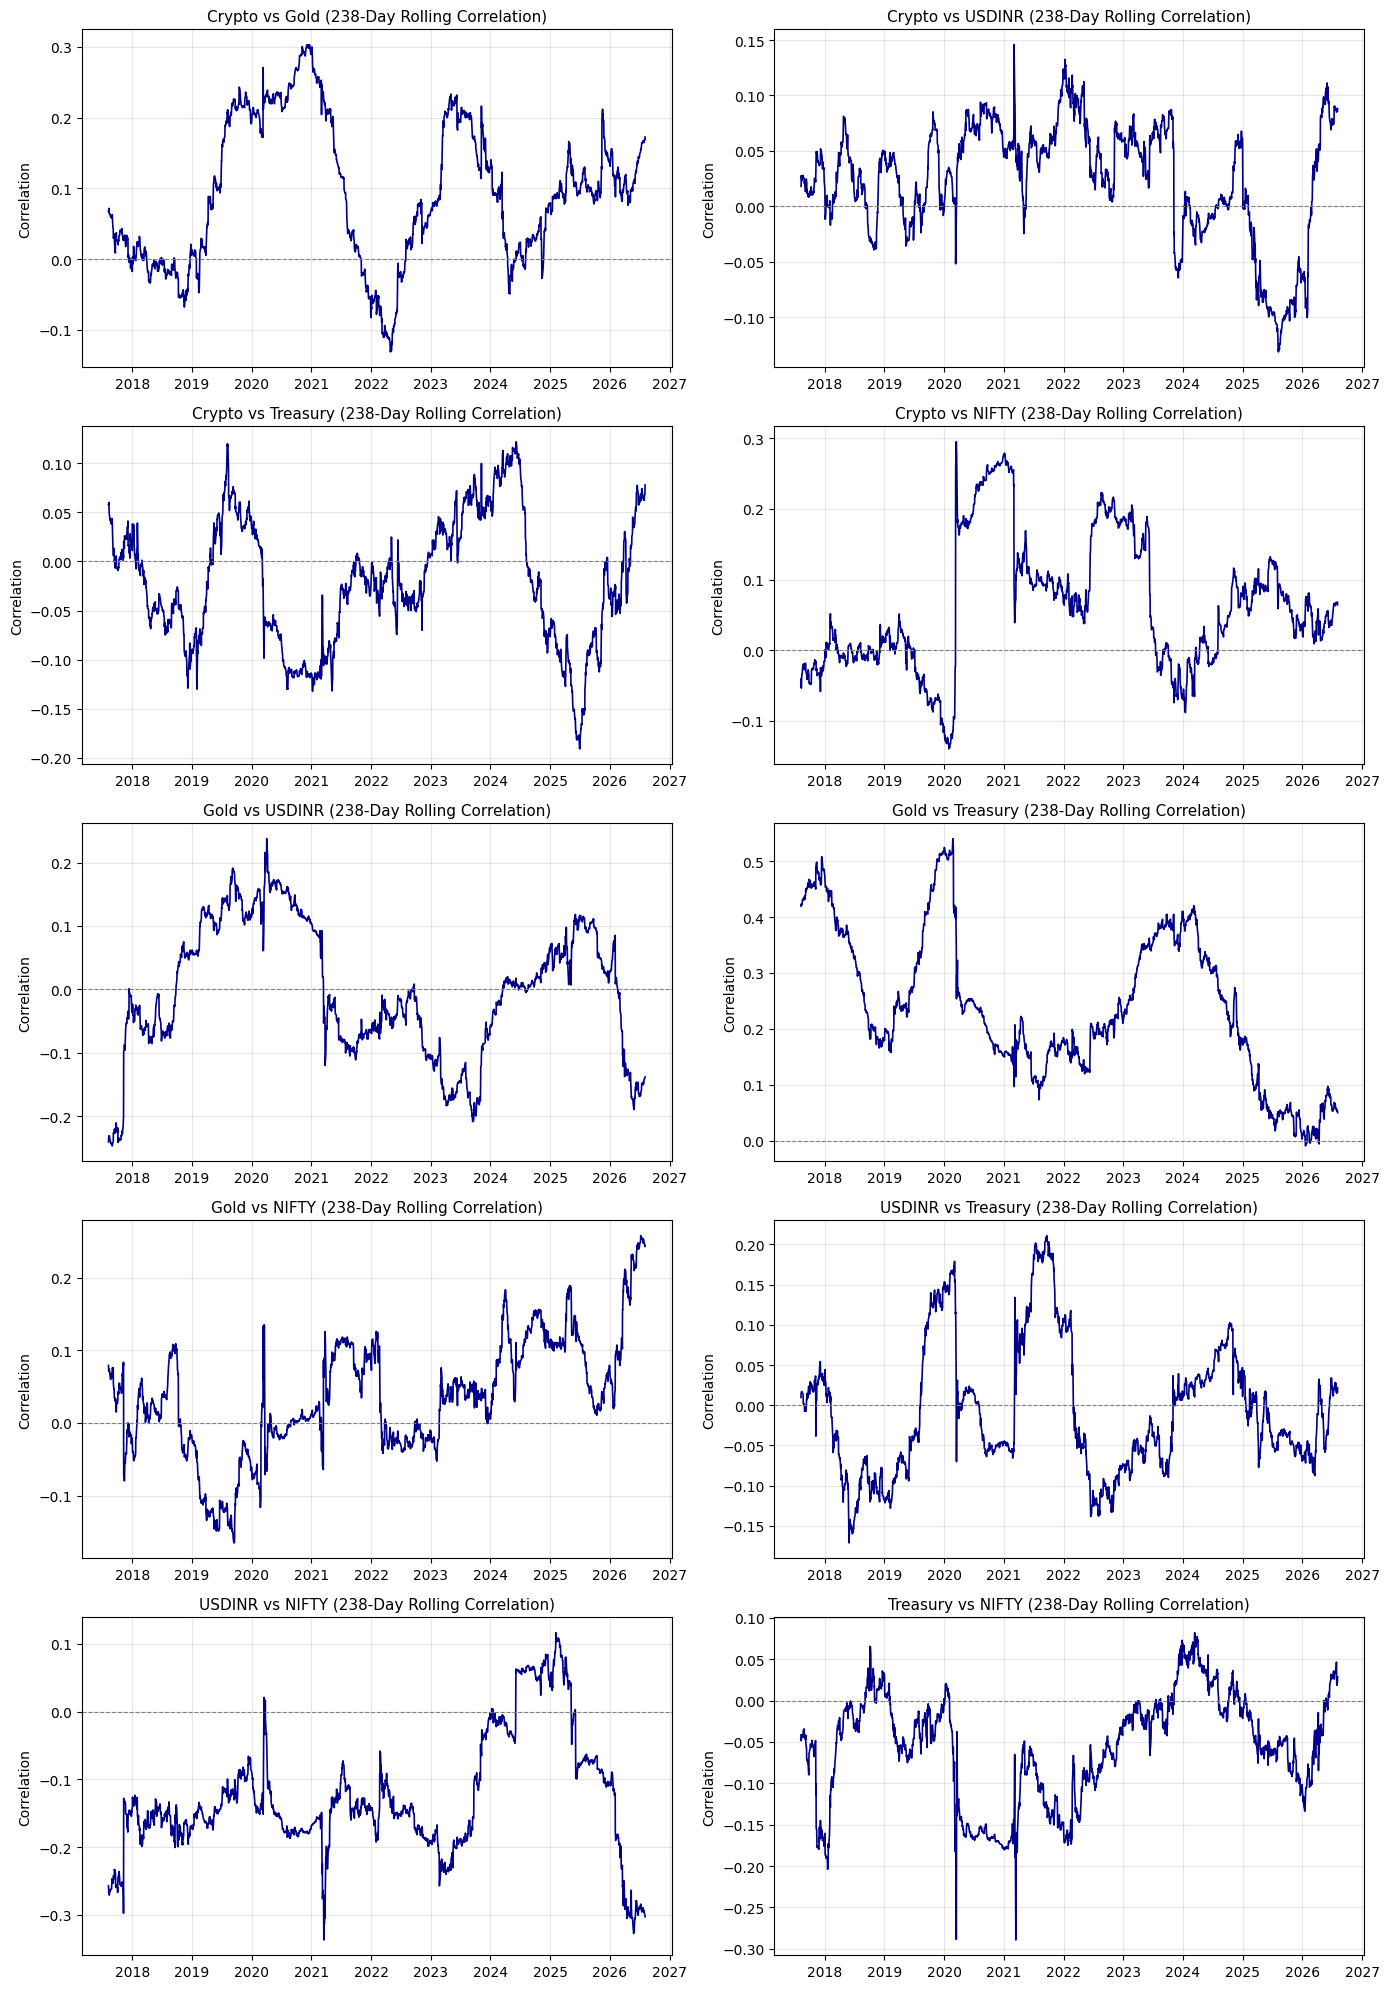

In [312]:
window = 238

pairs = list(itertools.combinations(returns.columns, 2))

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, (asset1, asset2) in enumerate(pairs):
    
    rolling_corr = (
        returns[asset1]
        .rolling(window)
        .corr(returns[asset2])
    )
    
    axes[i].plot(
        rolling_corr.index,
        rolling_corr,
        linewidth=1.2,
        color='darkblue'
    )
    
    axes[i].axhline(0, color='grey', linestyle='--', linewidth=0.8)
    axes[i].set_title(
        f'{asset1} vs {asset2} ({window}-Day Rolling Correlation)',
        fontsize=11
    )
    axes[i].set_ylabel('Correlation')
    axes[i].grid(True, alpha=0.3)

for j in range(len(pairs), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()